(example_ot_binary_classification_example)=

# Optimal Transport models for binary classification problem.

## Importing necesary moduls

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

from uniharmony import verbosity
from uniharmony.datasets import make_multisite_classification
from uniharmony.ot import OptimalTransportDomainAdaptation


sns.set_theme(style="whitegrid")
verbosity("warning")

## Generate data using `unharmony` function

In [2]:
X, y, sites = make_multisite_classification(n_sites=3, n_features=2, site_effect_strength=10)

X_train, X_val, y_train, y_val, sites_train, sites_val = train_test_split(X, y, sites, test_size=0.5, random_state=42)

### Let's create a instance of the OTDA harmonizer

In [3]:
otda = OptimalTransportDomainAdaptation()

# Fit the transformer to adapts sites 1 and 2, to be similar to site 0
otda.fit(X=X_train, sites=sites_train, y=y_train, ref_site=0)
# Transform the validation data
X_harmonized = otda.transform(X=X_val, sites=sites_val)

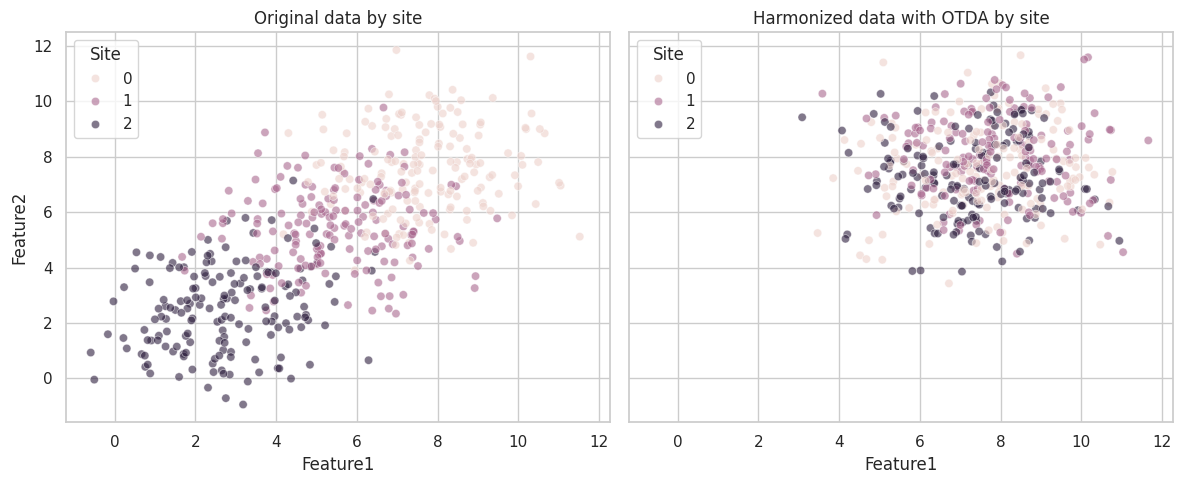

In [4]:
df_orig = pd.DataFrame(X_train, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites_train

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites_val

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data with OTDA by site")
plt.tight_layout()

# Take home
The transported validation samples are now similar to site `0`.